# Aprenentatge profund per a imatges

A les lliçons anteriors, hem treballat extensament amb **dades tabulars**. Aquests conjunts de dades són generalment fàcils de representar i analitzar utilitzant eines com `pandas`, `scikit-learn` i diversos models estadístics.

Tanmateix, les **imatges** són fonamentalment diferents tant en estructura com en contingut. En lloc de files i columnes amb característiques etiquetades explícitament, una imatge és una graella de valors de píxels, normalment en 2D per a escala de grisos o en 3D per a color (alçada × amplada × canals). Per exemple, una imatge en color de mida 224×224 píxels amb 3 canals de color (RGB) conté més de 150.000 valors en brut, cap dels quals no està etiquetat amb característiques interpretables per humans com “edat” o “ingrés”.

Aquesta diferència condueix a diversos reptes importants:

- **Alta dimensionalitat**: Les imatges contenen moltes més característiques (píxels) que els conjunts de dades tabulars típics, cosa que augmenta la complexitat computacional i el risc de *overfitting*.
- **Estructura espacial**: Els píxels propers en una imatge sovint estan relacionats, formant vores, textures i patrons. Els models tabulars generalment no capten aquestes dependències locals.
- **Bretxa semàntica**: La relació entre els píxels en brut i els conceptes significatius (com un moic, una cara o un senyal de trànsit) és complexa i no lineal, i requereix models sofisticats per salvar aquesta bretxa.


En aquest mòdul explorarem com treballar amb dades d’imatges Per fer-ho, tornarem a utilitzar `PyTorch`.

## *Batches*

Quan entrenem models d’aprenentatge profund amb imatges, no alimentem tot el conjunt de dades alhora, com fèiem amb les dades tabulars. En lloc d’això, agrupem múltiples imatges en *batches*.

Un *batch* és una col·lecció de mostres (p. ex. imatges i les seves etiquetes) processades juntes en una sola passada endavant i enrere. Com a resultat les dades d'imatge són representades com un tensor de 4 dimensions:

```
(batch_size, channels, height, width)
```

## El conjunt de dades MNIST

**MNIST** (*Modified National Institute of Standards and Technology*) consta de **70.000 imatges en escala de grisos** de xifres manuscrites (0–9):

- **60.000 imatges d'entrenament**
- **10.000 imatges de prova**

Cada imatge és de **28 × 28 píxels**, d'**un sol canal** i està **etiquetada** amb la xifra correcta. És un conjunt petit, net i preprocessat, però amb una variabilitat realista en l'escriptura.

![MNIST Examples](https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png)

Cada fila mostra les xifres 0–9 escrites per persones diferents. Algunes xifres s'escriuen de maneres molt diferents, i per això necessitem aprenentatge automàtic per reconèixer-les.reconèixer-les automàticament.

In [13]:
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from tqdm import tqdm

## Carrega de dades

El processament de dades, com ja hem vist, és una part fonamental de qualsevol projecte d'aprenentatge profund. Per treballar amb dades de manera eficient, PyTorch ofereix dues classes: ``Dataset`` i ``DataLoader``.

El ``Dataset`` és una classe que representa un conjunt de dades. Serveix per carregar, transformar i accedir als elements individuals del conjunt. PyTorch inclou diversos datasets predefinits com MNIST, CIFAR-10 o ImageNet, però també podem crear els nostres propis datasets personalitzats heretant de torch.utils.data.Dataset i implementant els mètodes __len__() i __getitem__().

Un cop tenim el dataset, el ``DataLoader`` s’encarrega de gestionar la manera com aquestes dades s’entreguen al model. Permet dividir les dades en **batches**, barrejar-les (shuffle) i carregar-les en paral·lel utilitzant múltiples fils (*workers*).

> **Bona pràctica:** barregem (`shuffle=True`) el conjunt d'entrenament perquè els batches no segueixin sempre el mateix ordre, però no ho feim a validació.

In [14]:
BATCH_SIZE = 64
transform = transforms.Compose([
    transforms.ToTensor(),  # PIL [0,255] -> tensor float [0,1] amb forma (C, H, W)
])

dataset_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
dataset_val = datasets.MNIST(root='data', train=False, download=True, transform=transform)

dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)   # barregem només l'entrenament
dataloader_val = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
img, gt = dataset_train[0]
print("Una imatge del Dataset:", img.shape, "| etiqueta:", gt)

batch, gts = next(iter(dataloader_train))
print("Un batch del DataLoader:", batch.shape, gts.shape)

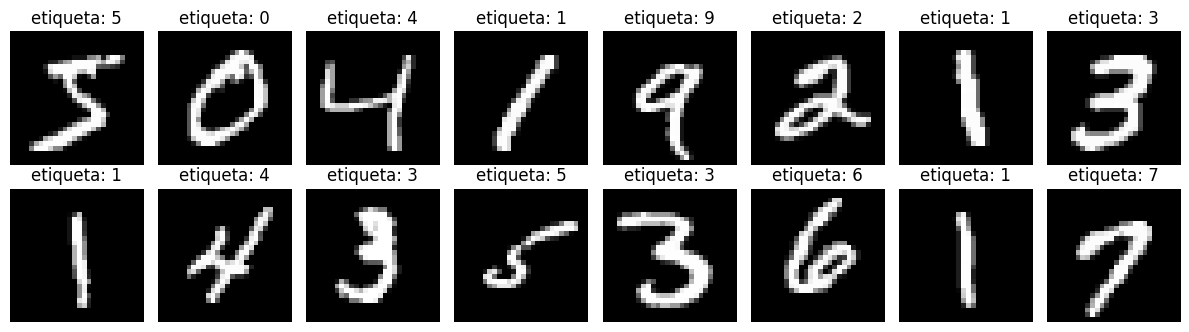

In [15]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, (img, gt) in zip(axes.ravel(), (dataset_train[i] for i in range(16))):
    ax.imshow(img.squeeze(0), cmap="gray"); ax.set_title(f"etiqueta: {gt}"); ax.axis("off")
plt.tight_layout(); plt.show()

---
### `nn.Sequential`

`nn.Sequential` és una manera senzilla de construir una xarxa apilant les capes en ordre. És útil quan el model és una cadena lineal de capes, sense ramificacions ni lògica personalitzada.

Una imatge és un tensor `(1, 28, 28)`, però una capa `Linear` espera un vector. Per això el primer pas és `nn.Flatten()`, que converteix cada imatge de `(1, 28, 28)` en un vector de `784` valors (mantenint la dimensió del batch).


In [ ]:
mlp_net = nn.Sequential(
    torch.nn.Linear(784, 10),
    nn.ReLU(),
    torch.nn.Linear(10, 10),
    torch.nn.Dropout(0.2),
    nn.ReLU(),
    torch.nn.Linear(10, 10)
)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(mlp_net)
print("Paràmetres entrenables:", count_params(mlp_net))

### Entrenament

L'entrenament ja el vàrem veure la setmana passada. Ara només canvia la introducció del *batch* i el que això suposa. Per entrenar una xarxa repetim, per cada *batch*, quatre passos:

1. **Pèrdua**: comparem les prediccions amb les etiquetes reals.
2. **Gradients**: `loss.backward()` calcula com canvia la pèrdua respecte a cada pes.
3. **Optimització**: `optimizer.step()` actualitza els pesos.
4. **Avaluació**: mesurem mètriques (pèrdua i *accuracy*).

In [ ]:
EPOCHS = #TODO
loss_fn = # TODO
LR = #TODO
optimizer = #TODO

In [ ]:
running_loss = []
running_acc = []

running_test_loss = []
running_test_acc = []

for t in tqdm(range(EPOCHS), desc="Epochs"):
    batch_loss = 0
    batch_acc = 0

    i_batch = 0
    for i_batch, (x, y) in enumerate(dataloader_train):  # We have to iter the batches.
        mlp_net.train()
        x = x.reshape(x.shape[0], -1)  # Flatten images

        optimizer.zero_grad()
        y_pred = mlp_net(x)

        # 1. LOSS CALCULATION
        loss = loss_fn(y_pred, y)

        # 2. GRADIENT
        loss.backward()

        # 3. OPTIMISATION
        optimizer.step()

        # 4. EVALUATION
        mlp_net.eval()  # Mode avaluació de la xarxa
        y_pred = mlp_net(x)
        y_pred_binary = torch.argmax(y_pred, 1).double()

        batch_loss += (loss_fn(y_pred, y).detach())
        batch_acc += accuracy_score(y_pred_binary.detach(), y.detach())

    running_loss.append(batch_loss / (i_batch + 1))
    running_acc.append(batch_acc / (i_batch + 1))

## Exercici

### MNIST
1. Seleccionar la funció de pèrdua a emprar per poder entrenar el model.
2. Afegir la validació al bucle del `MNIST` i contestar a la pregunta de si hi ha *overfitting*.


### Dataset propi

Ara passarem de MNIST (preparat per PyTorch) a un cas més realista: un conjunt d'imatges que hem de carregar nosaltres.

[`ImageFolder`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html) assumeix que les imatges s'organitzen en una carpeta per classe i n'utilitza el nom de la carpeta com a etiqueta:

```
arrel/
├── classe_a/  img1.png  img2.png ...
├── classe_b/  ...
└── classe_c/  ...
```

Trobareu el dataset a l'[enllaç](https://github.com/miquelmn/aa_2627/releases/download/pr3/p4.tar.gz/pr3/p4.tar.gz).

0. Analitza l'estructura de carpetes i quines imatges hi ha.
1. Crear dos objectes `DataLoader` pel dataset. Empra l'estructura de dades `transform` que faci, com a mínim, `Resize((alçada, amplada))`, `ToTensor()` i `Normalize(mean, std)` (per exemple, mitjana i desviació 0.5 a cada canal, que porta els valors a [-1, 1]).
2. Entrenar un **MLP** amb `PyTorch` per tal d'identificar les classes. Prova primer amb una mida d'imatges més petita (64 per 64 píxels) fins a la mida original.
3. Repeteix l'experiment amb una mida **més petita** (p. ex. 32 × 32) i amb la **mida original** de les imatges. 